In [1]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [10]:
df = df.rename(columns={
    'v1': 'label',
    'v2': 'message'
})

df.head()

,label,message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [11]:
df = df[['label', 'message']]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [13]:
df.info()
df.describe(include='all')
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
label,
ham,4825
spam,747


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 403


In [15]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 5169


In [17]:
print("Missing values:")
df.isnull().sum()

Missing values:


,0
label,0
message,0


In [18]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


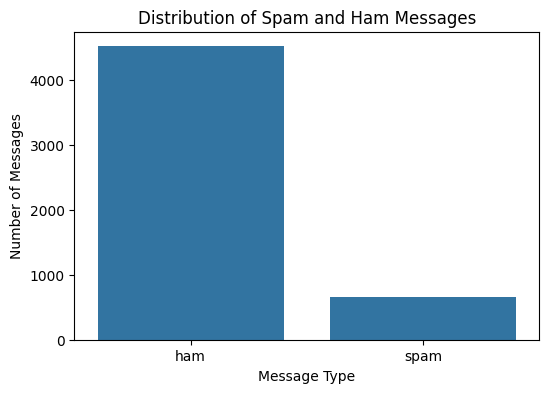

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')

plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [24]:
df['message_length'] = df['message'].str.len()

In [25]:
df['word_count'] = df['message'].str.split().str.len()

In [26]:
df['digit_count'] = df['message'].str.count(r'\d')

In [28]:
df[['message', 'message_length', 'word_count', 'digit_count']].head()

,message,message_length,word_count,digit_count
0,"Go until jurong point, crazy.. Available only ...",111,20,0
1,Ok lar... Joking wif u oni...,29,6,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,25
3,U dun say so early hor... U c already then say...,49,11,0
4,"Nah I don't think he goes to usf, he lives aro...",61,13,0


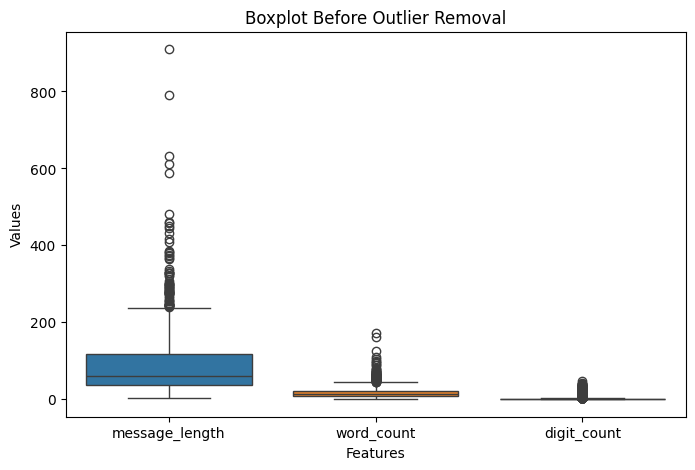

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[
    ['message_length', 'word_count', 'digit_count']
])

plt.title('Boxplot Before Outlier Removal')
plt.xlabel('Features')
plt.ylabel('Values')

plt.show()

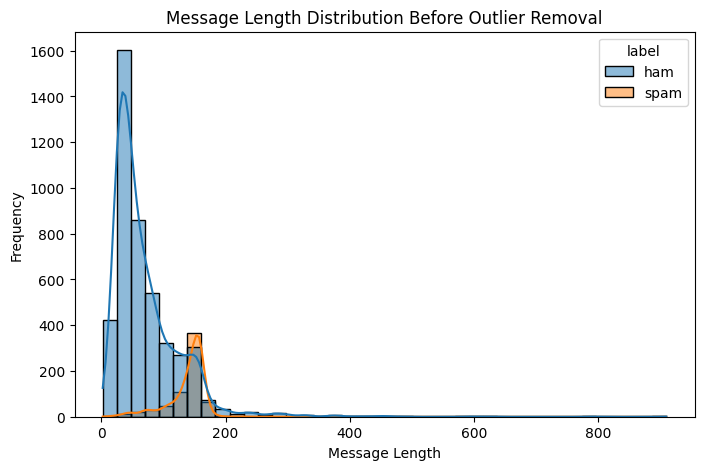

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=40,
    kde=True
)

plt.title('Message Length Distribution Before Outlier Removal')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

In [31]:
numeric_features = [
    'message_length',
    'word_count',
    'digit_count'
]

for column in numeric_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Feature:", column)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("--------------------------------")

Feature: message_length
Lower Bound: -85.5
Upper Bound: 238.5
Number of Outliers: 66
--------------------------------
Feature: word_count
Lower Bound: -15.5
Upper Bound: 44.5
Number of Outliers: 68
--------------------------------
Feature: digit_count
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 705
--------------------------------


In [32]:
df_clean = df.copy()

In [33]:
for column in numeric_features:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("Original dataset size:", len(df))
print("Dataset size after outlier removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original dataset size: 5169
Dataset size after outlier removal: 4401
Rows removed: 768


In [35]:
df_clean.head()
df_clean.shape

(4401, 6)

In [36]:
df_clean.isnull().sum()

,0
label,0
message,0
label_num,0
message_length,0
word_count,0
digit_count,0


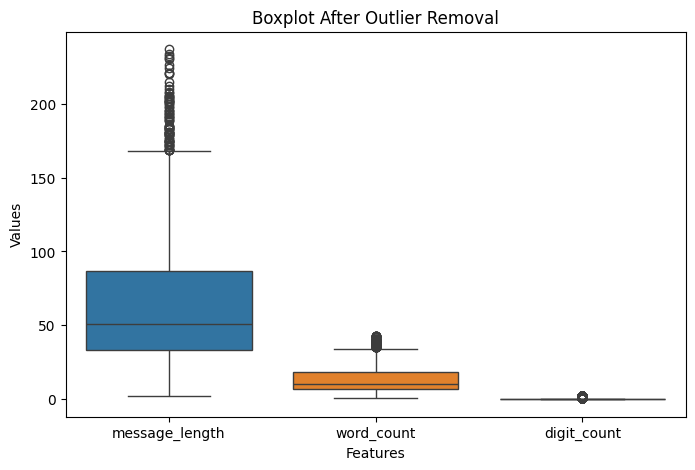

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean[
    ['message_length', 'word_count', 'digit_count']
])

plt.title('Boxplot After Outlier Removal')
plt.xlabel('Features')
plt.ylabel('Values')

plt.show()

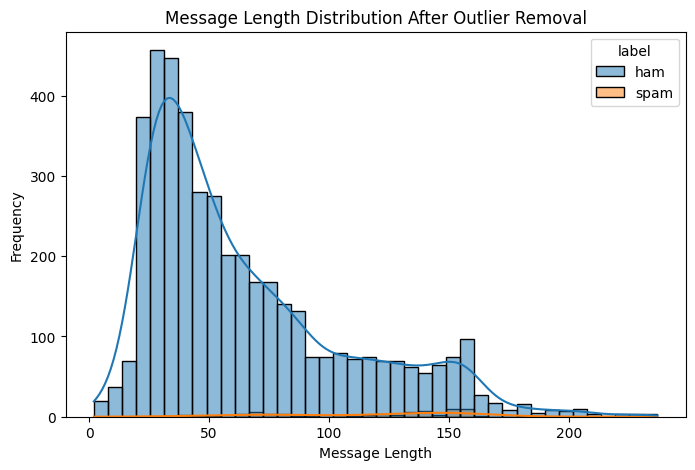

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x='message_length',
    hue='label',
    bins=40,
    kde=True
)

plt.title('Message Length Distribution After Outlier Removal')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

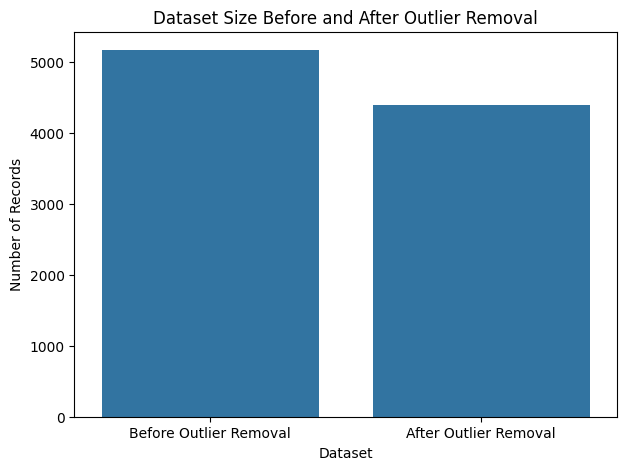

In [39]:
comparison = pd.DataFrame({
    'Dataset': ['Before Outlier Removal', 'After Outlier Removal'],
    'Number of Records': [len(df), len(df_clean)]
})

plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x='Dataset',
    y='Number of Records'
)

plt.title('Dataset Size Before and After Outlier Removal')
plt.ylabel('Number of Records')

plt.show()

In [41]:
X = df['message']
y = df['label_num']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [43]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [44]:
model_before = LogisticRegression(
    max_iter=1000
)

model_before.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [45]:
y_pred_before = model_before.predict(
    X_test_tfidf
)

In [46]:
accuracy_before = accuracy_score(
    y_test,
    y_pred_before
)

print("Accuracy BEFORE Outlier Removal:",
      accuracy_before)

Accuracy BEFORE Outlier Removal: 0.9584139264990329


In [50]:
print("Classification Report BEFORE Outlier Removal:")
print(
    classification_report(
        y_test,
        y_pred_before,
        target_names=['Ham', 'Spam']
    )
)

Classification Report BEFORE Outlier Removal:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.68      0.81       131

    accuracy                           0.96      1034
   macro avg       0.97      0.84      0.89      1034
weighted avg       0.96      0.96      0.96      1034



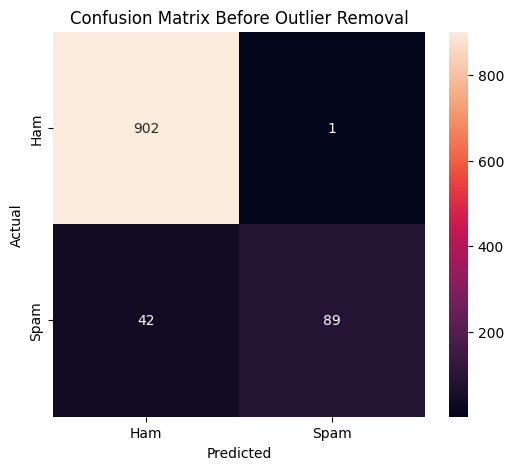

In [51]:
cm_before = confusion_matrix(
    y_test,
    y_pred_before
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_before,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix Before Outlier Removal')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [52]:
X_after = df_clean['message']
y_after = df_clean['label_num']

In [53]:
X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(
    X_after,
    y_after,
    test_size=0.20,
    random_state=42,
    stratify=y_after
)

print("Training samples after removal:", len(X_train_after))
print("Testing samples after removal:", len(X_test_after))

Training samples after removal: 3520
Testing samples after removal: 881


In [54]:
vectorizer_after = TfidfVectorizer(
    stop_words='english'
)

X_train_after_tfidf = vectorizer_after.fit_transform(
    X_train_after
)

X_test_after_tfidf = vectorizer_after.transform(
    X_test_after
)

In [55]:
model_after = LogisticRegression(
    max_iter=1000
)

model_after.fit(
    X_train_after_tfidf,
    y_train_after
)

LogisticRegression(max_iter=1000)

In [56]:
y_pred_after = model_after.predict(
    X_test_after_tfidf
)

In [57]:
accuracy_after = accuracy_score(
    y_test_after,
    y_pred_after
)

print("Accuracy AFTER Outlier Removal:",
      accuracy_after)

Accuracy AFTER Outlier Removal: 0.9841089670828603


In [58]:
print("Classification Report AFTER Outlier Removal:")

print(
    classification_report(
        y_test_after,
        y_pred_after,
        target_names=['Ham', 'Spam']
    )
)

Classification Report AFTER Outlier Removal:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       867
        Spam       0.00      0.00      0.00        14

    accuracy                           0.98       881
   macro avg       0.49      0.50      0.50       881
weighted avg       0.97      0.98      0.98       881



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


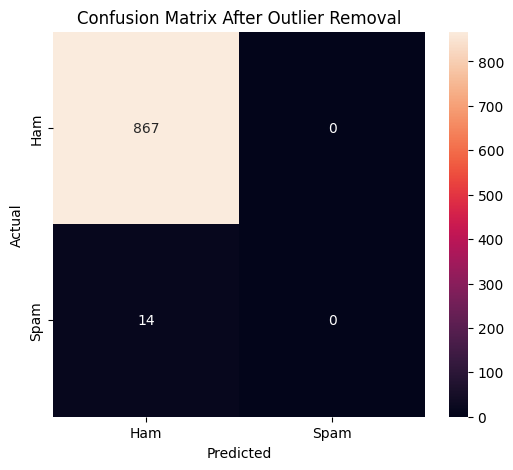

In [59]:
cm_after = confusion_matrix(
    y_test_after,
    y_pred_after
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_after,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix After Outlier Removal')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [60]:
results = pd.DataFrame({
    'Stage': [
        'Before Outlier Removal',
        'After Outlier Removal'
    ],
    'Accuracy': [
        accuracy_before,
        accuracy_after
    ]
})

print(results)

                    Stage  Accuracy
0  Before Outlier Removal  0.958414
1   After Outlier Removal  0.984109


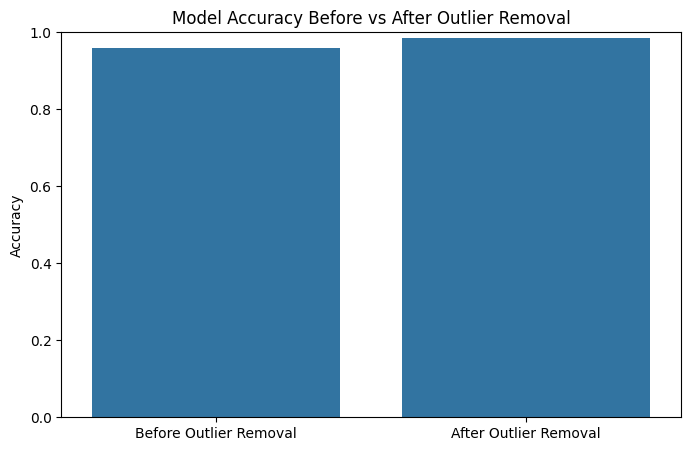

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Stage',
    y='Accuracy'
)

plt.title('Model Accuracy Before vs After Outlier Removal')
plt.ylabel('Accuracy')
plt.xlabel('')

plt.ylim(0, 1)

plt.show()